# 04 S 曲线与前瞻

刀路切成 block 之后，每个 block 内走一段什么样的速度曲线？相邻 block 的连接点速度取多少，才能保证来得及加速、减速？这一节回答：

1. jerk 受限的 S 曲线（feedrate profile）长什么样，状态 $[s, v, a, j]$ 怎么逐段推进？
2. 一段 block 内怎么规划：七段 S 曲线 `seven_phase` 与五段 S 曲线 `five_phase`？
3. 连接点的速度上限从哪来：弓高误差、法向加速度、法向 jerk 三条几何限速？
4. 前瞻（look-ahead）的双向扫描为什么只要正反两遍？
5. 整条刀路怎样由 `schedule` 拼出一条完整的进给轮廓，插补后真的不超限吗？

**前置知识**：导数栈的形状约定 `(4, ...)`（$d[k]$ 是第 $k$ 阶导数）、曲线的弧长参数化与刀路的 block 结构（见 [01](01_曲线与导数栈.ipynb)、[02](02_弧长表与进给波动.ipynb) 与 [../docs/数学约定.md](../docs/数学约定.md) 第 1–3 节）。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. 分段恒 jerk 的进给轮廓

数控系统每个插补周期（interpolation period，$T_s$，通常 1 ms 量级）要算出一个刀尖位置。如果让速度阶跃，加速度就是无穷大，机床跟不上；让加速度阶跃，jerk 无穷大，会引起振动。所以进给速度的规划普遍采用**分段恒 jerk** 的曲线：jerk 取分段常数，加速度是分段线性（连续），速度是分段二次——这就是 S 曲线（S-curve）。

一段之内，从状态 $[s_0, v_0, a_0]$ 出发、jerk 恒为 $j$、经过 $\tau$ 秒：

$$
s = s_0 + v_0\tau + \tfrac12 a_0\tau^2 + \tfrac16 j\tau^3,\qquad
v = v_0 + a_0\tau + \tfrac12 j\tau^2,\qquad
a = a_0 + j\tau .
$$

库里的 `profiles.Profile` 就是一串 (时长, jerk)：求值 `profile(t)` 返回 $[s, v, a, j]$，形状 `(4, ...)`——正好是 $s(t)$ 的导数栈，与全库约定一致；另有 `duration`（总时长）和 `length`（总路程）两个属性。插补器只依赖这三样。

**速度过渡** `transition(v0, v1, A, J)`：端点加速度都为零、从 $v_0$ 变到 $v_1$ 的最快方式是"加加速、匀加速、减加速"三段。记 $\Delta v = |v_1 - v_0|$：

$$
T_j = \min\!\left(\frac{A}{J},\ \sqrt{\frac{\Delta v}{J}}\right),\qquad
T_a = \frac{\Delta v}{J\,T_j} - T_j .
$$

- $\Delta v \le A^2/J$：加速度还没爬到 $A$ 就得回头，$T_a = 0$，$a$ 曲线是**三角形**，峰值 $\sqrt{J\Delta v}$；总时长 $T = 2\sqrt{\Delta v/J}$。
- $\Delta v > A^2/J$：有一段匀加速，$a$ 曲线是**梯形**，峰值就是 $A$；总时长 $T = \Delta v/A + A/J$。

速度曲线关于过渡中点对称，所以平均速度恰为 $(v_0+v_1)/2$，过渡距离 $= \frac{v_0+v_1}{2}(2T_j + T_a)$——这个对称性后面讲前瞻时还要用到。

In [3]:
from cnc5x import limits, look_ahead, metrics, profiles

V_MAX, A_MAX, J_MAX, TS = 100.0, 3000.0, 60000.0, 0.0005  # mm/s、mm/s²、mm/s³、s

# 阈值 A²/J = 150 mm/s：两种情况各取一个例子
dv1, dv2 = 10.0, 50.0
d1, j1 = profiles.transition(0.0, dv1, A_MAX, J_MAX)
a_demo = 1000.0  # 演示梯形用：把 A 调小，让 dv2 > A²/J = 16.7
d2, j2 = profiles.transition(0.0, dv2, a_demo, J_MAX)
print(f"A²/J = {A_MAX**2 / J_MAX:.0f} mm/s")
print(f"dv = {dv1}: 时长 {d1.sum():.6f} s，解析 2√(dv/J) = {2 * np.sqrt(dv1 / J_MAX):.6f} s")
print(f"dv = {dv2}, A = {a_demo}: 时长 {d2.sum():.6f} s，解析 dv/A + A/J = {dv2 / a_demo + a_demo / J_MAX:.6f} s")

A²/J = 150 mm/s
dv = 10.0: 时长 0.025820 s，解析 2√(dv/J) = 0.025820 s
dv = 50.0, A = 1000.0: 时长 0.066667 s，解析 dv/A + A/J = 0.066667 s


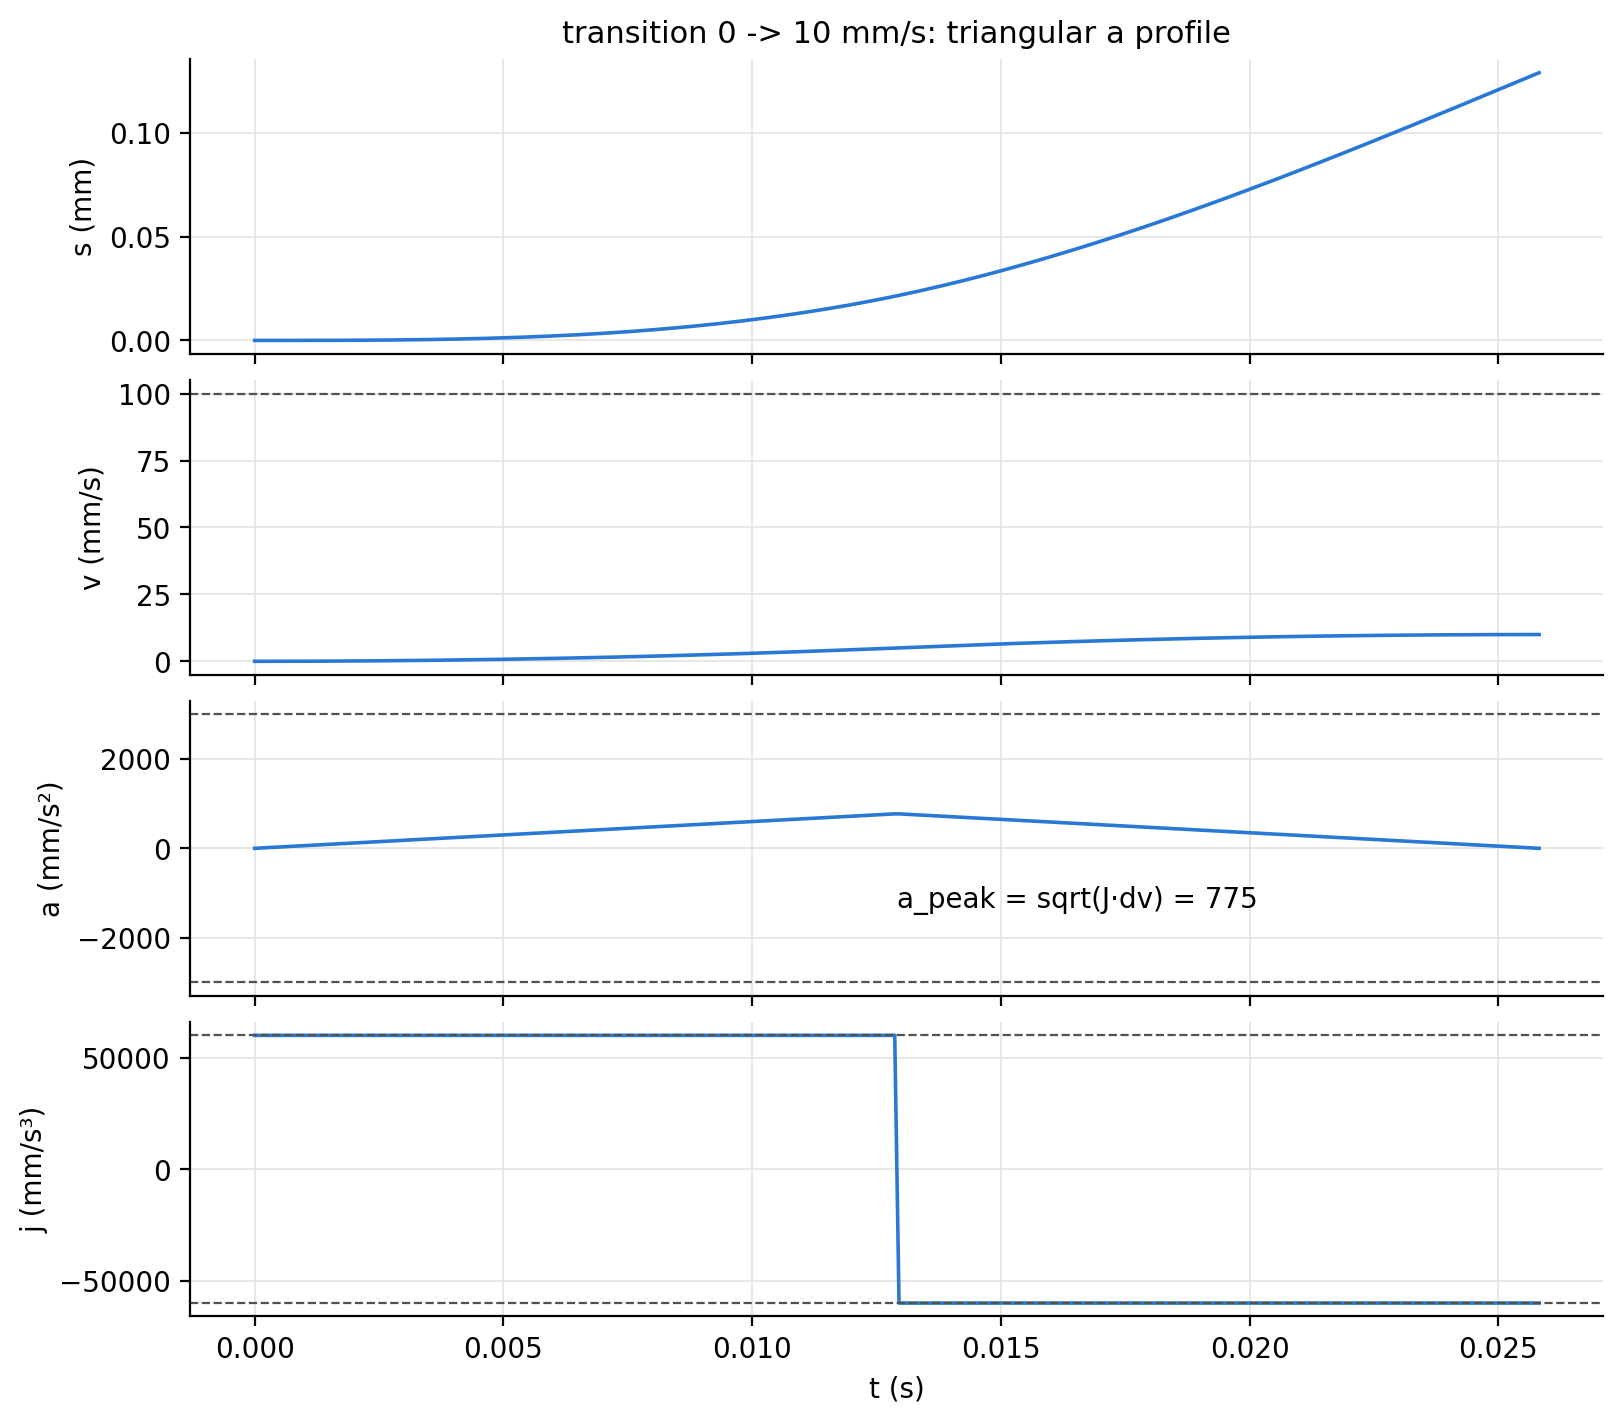

In [4]:
# 三角形情形：a 的峰值到不了 A
p1 = profiles.Profile(d1, j1)
t1 = np.linspace(0, p1.duration, 300)
axes = plotting.plot_feed(t1, p1(t1), limits=(V_MAX, A_MAX, J_MAX))
axes[2].annotate(f"a_peak = sqrt(J·dv) = {np.sqrt(J_MAX * dv1):.0f}", xy=(0.5, 0.3), xycoords="axes fraction")
axes[0].set_title("transition 0 -> 10 mm/s: triangular a profile")
plt.show()

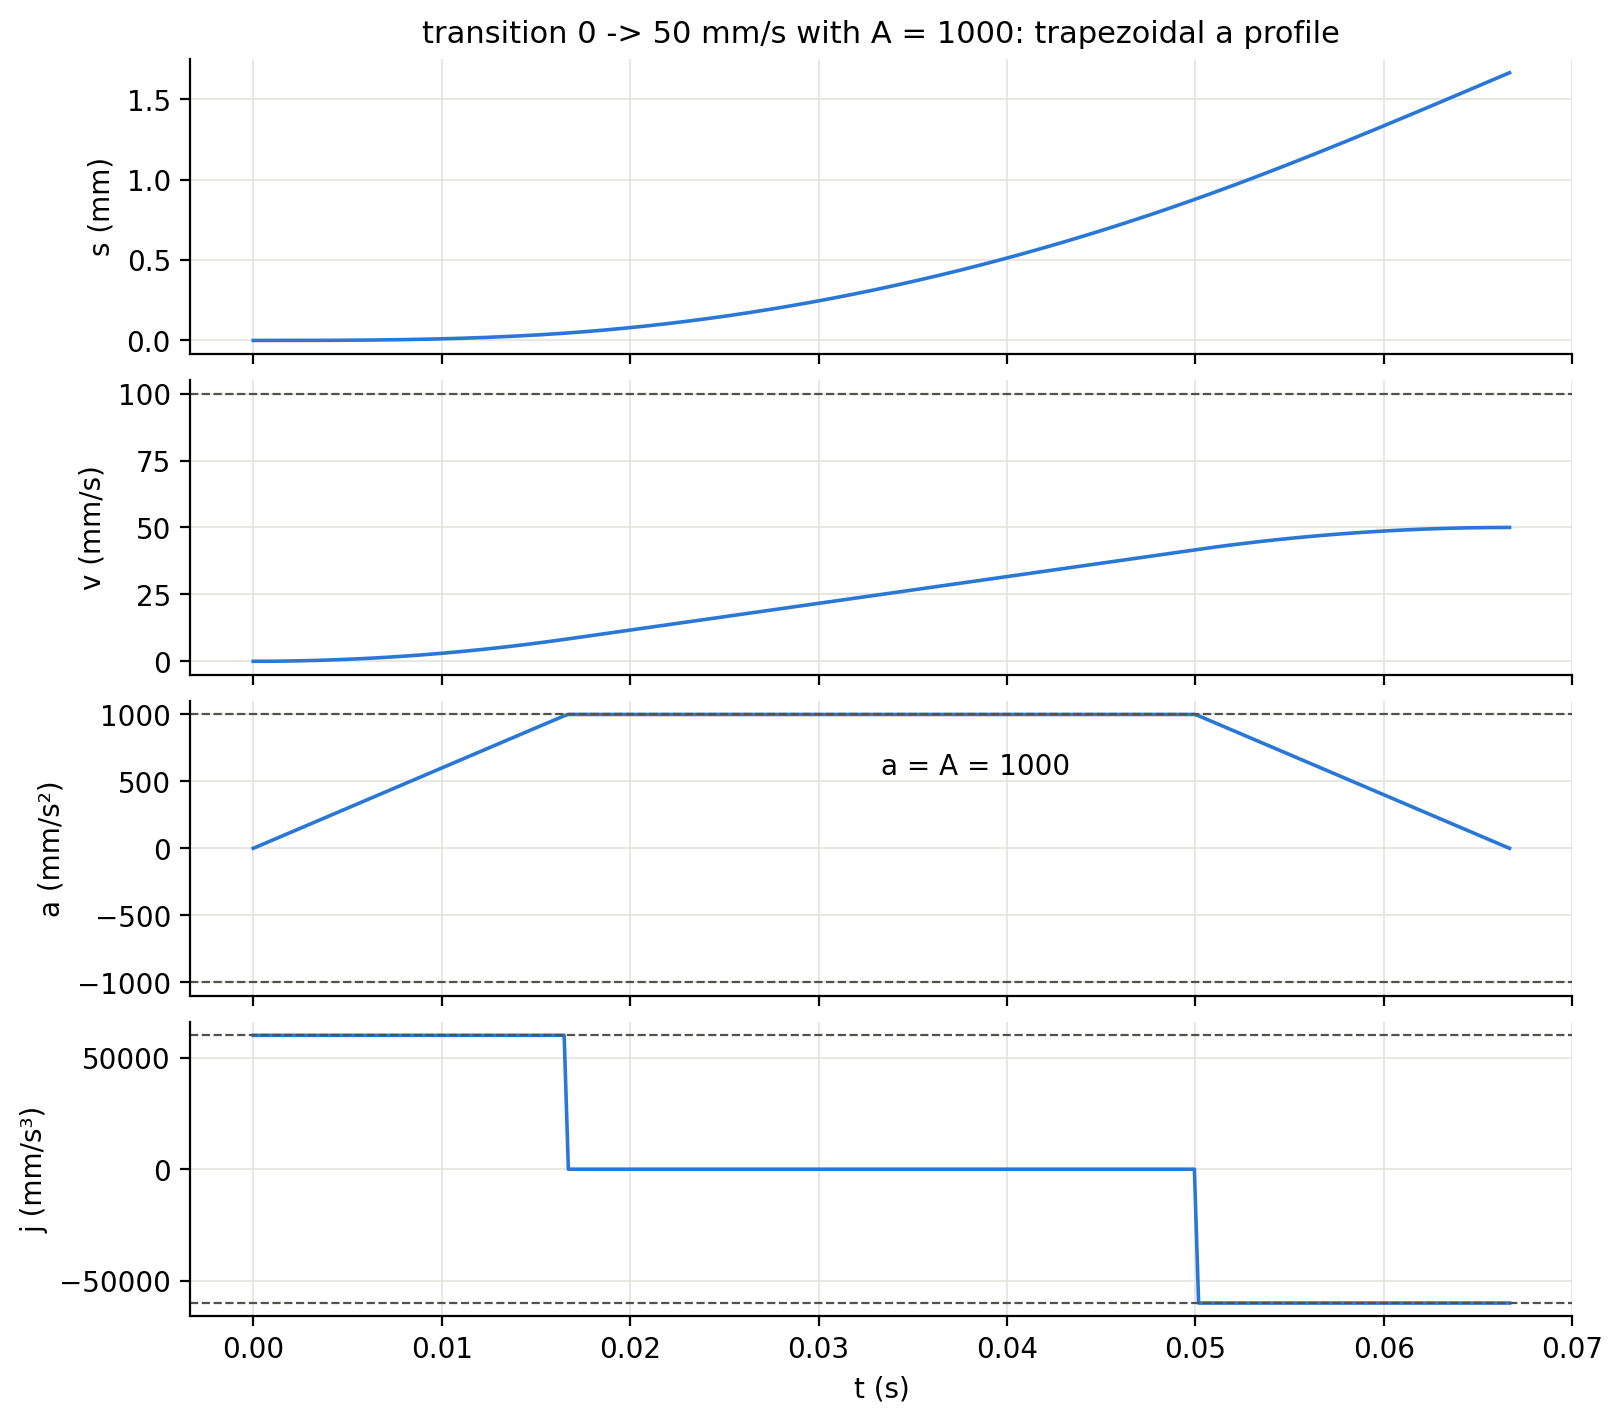

In [5]:
# 梯形情形：有匀加速段，a 的峰值就是 A
p2 = profiles.Profile(d2, j2)
t2 = np.linspace(0, p2.duration, 300)
axes = plotting.plot_feed(t2, p2(t2), limits=(V_MAX, a_demo, J_MAX))
axes[2].annotate(f"a = A = {a_demo:.0f}", xy=(0.5, 0.75), xycoords="axes fraction")
axes[0].set_title("transition 0 -> 50 mm/s with A = 1000: trapezoidal a profile")
plt.show()

In [6]:
# 检查：过渡距离 = 平均速度 × 总时长（速度曲线关于中点对称）
D = profiles.transition_distance(0.0, dv1, A_MAX, J_MAX)
print(f"transition_distance = {D:.8f} mm，v_avg·T = {dv1 / 2 * d1.sum():.8f} mm")
assert abs(D - dv1 / 2 * d1.sum()) < 1e-12
# 检查：profile 末状态正好是 [D, v1, 0]
end = p1(p1.duration)
print(f"末状态 [s, v, a] = [{end[0]:.8f}, {end[1]:.8f}, {end[2]:.2e}]")
assert abs(end[1] - dv1) < 1e-12 and abs(end[2]) < 1e-9

transition_distance = 0.12909944 mm，v_avg·T = 0.12909944 mm
末状态 [s, v, a] = [0.12909944, 10.00000000, 0.00e+00]


**要点**：S 曲线就是"分段恒 jerk"的导数栈；`transition` 三段搞定端点加速度为零的速度过渡，$\Delta v$ 与 $A^2/J$ 的大小关系决定 $a$ 曲线是三角形还是梯形。

## 2. 一个 block 的规划：七段与五段 S 曲线

一个 block 长 $L$，进、出的连接点速度为 $v_0$、$v_1$（端点加速度为零），指令进给上限 $v_{\max}$。`seven_phase` 的做法：先经一次过渡加速到峰值速度 $v_p$，匀速巡航一段，再经一次过渡减到 $v_1$——最多七段（加加速、匀加速、减加速、匀速、减减速、匀减速、减加速……减速侧同样三段）。

两段过渡的总距离 $D(v_p)$ 随 $v_p$ 单调增加，于是：

- $D(v_{\max}) \le L$：$v_p = v_{\max}$，匀速段补足剩余距离；
- $D(v_{\max}) > L$：到不了 $v_{\max}$，用 `brentq` 解 $D(v_p) = L$ 求峰值速度；
- $L$ 连一次过渡（$v_0 \to v_1$）都放不下：报错。前瞻（第 5 节）的任务就是保证这种情况不发生。

当 $v_0 = v_1 = 0$ 且到不了 $v_{\max}$ 时，两段过渡都是三角形，可以白盒写出峰值速度：

$$
L = 2\cdot\frac{v_p}{2}\cdot 2\sqrt{\frac{v_p}{J}} = \frac{2\,v_p^{3/2}}{\sqrt{J}}
\quad\Longrightarrow\quad
v_p = \left(\frac{L}{2}\right)^{2/3} J^{1/3} .
$$

Profile(duration=1.08165 s, length=100, phases=5)


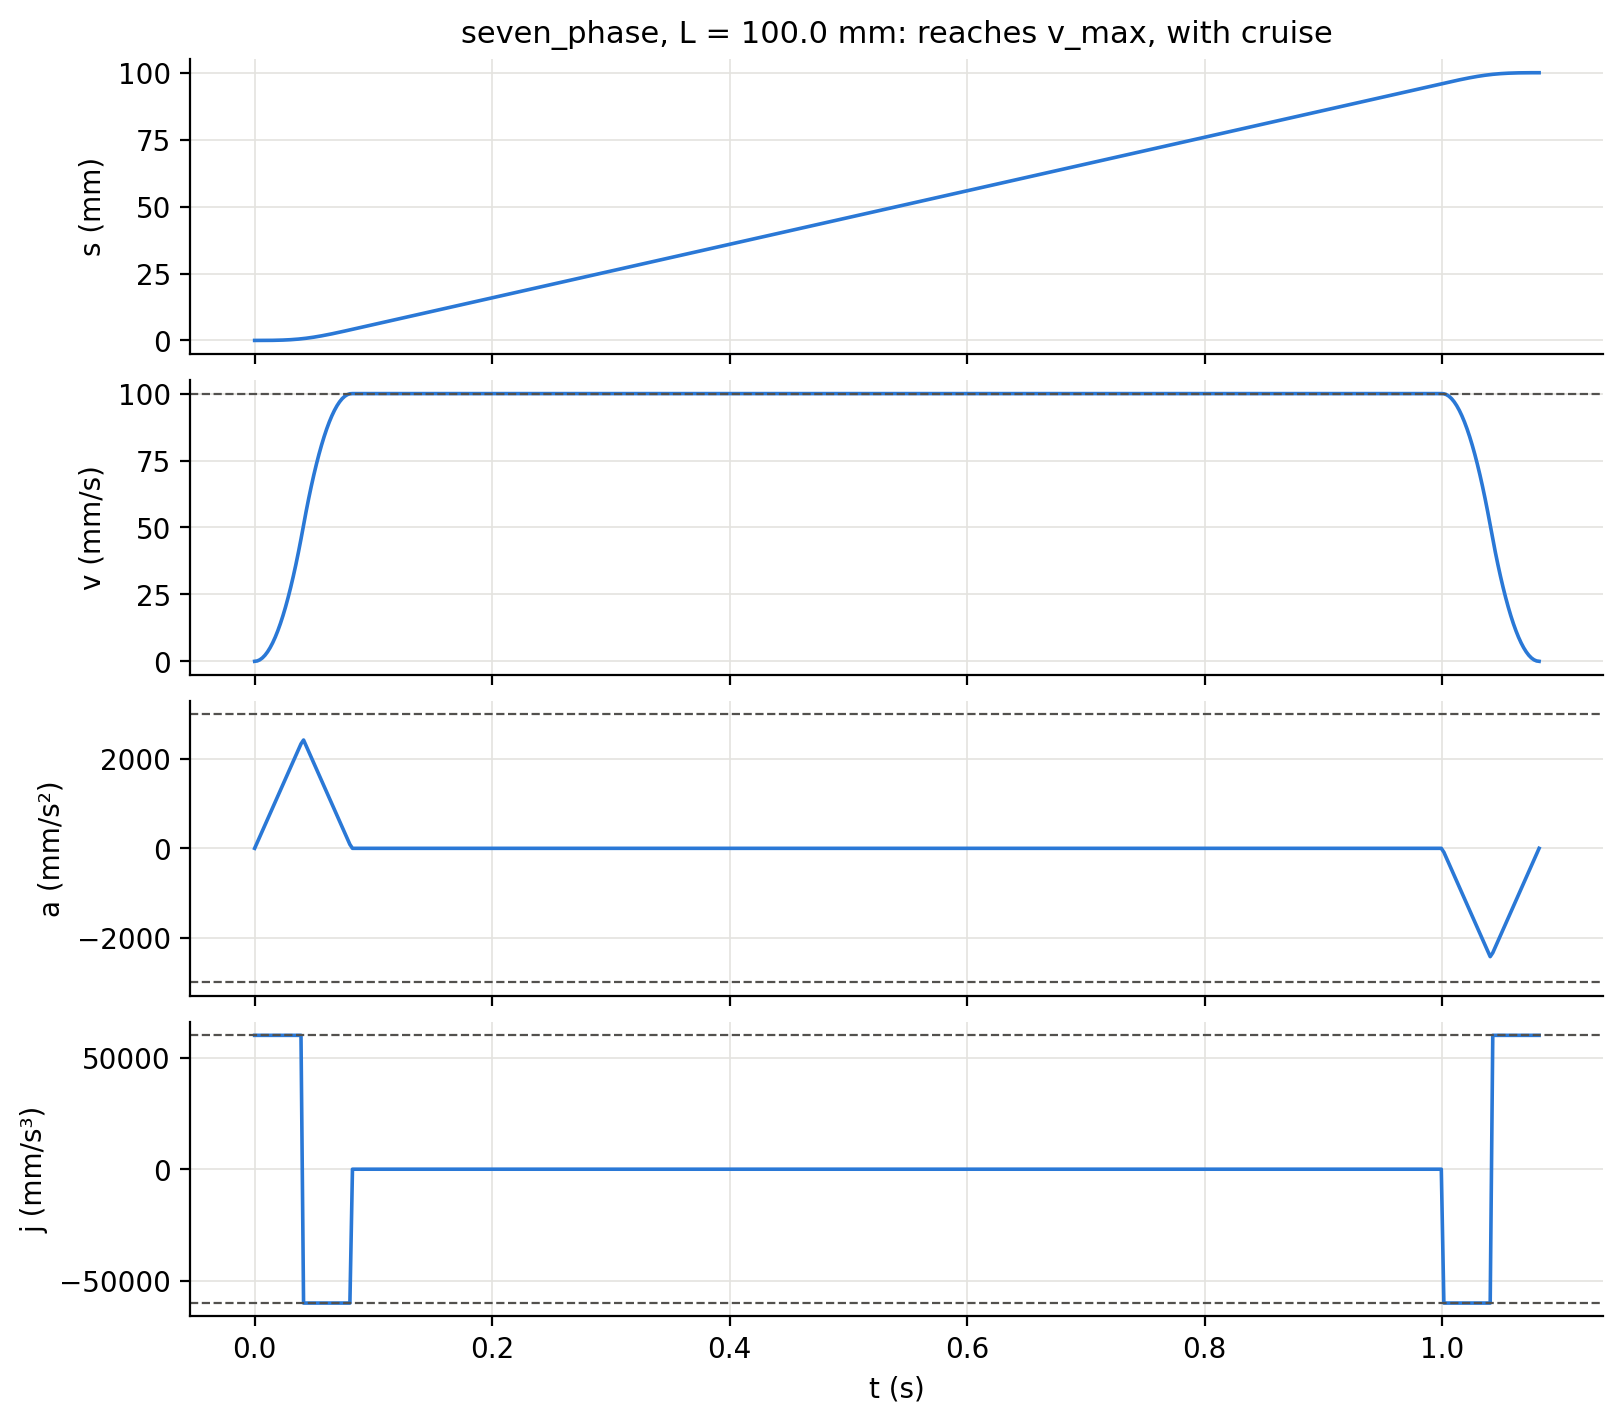

In [7]:
# 场景一：足够长，达到 v_max，有匀速段
L = 100.0
pa = profiles.seven_phase(L, 0.0, 0.0, V_MAX, A_MAX, J_MAX)
print(pa)
t = np.linspace(0, pa.duration, 500)
axes = plotting.plot_feed(t, pa(t), limits=(V_MAX, A_MAX, J_MAX))
axes[0].set_title(f"seven_phase, L = {L} mm: reaches v_max, with cruise")
plt.show()

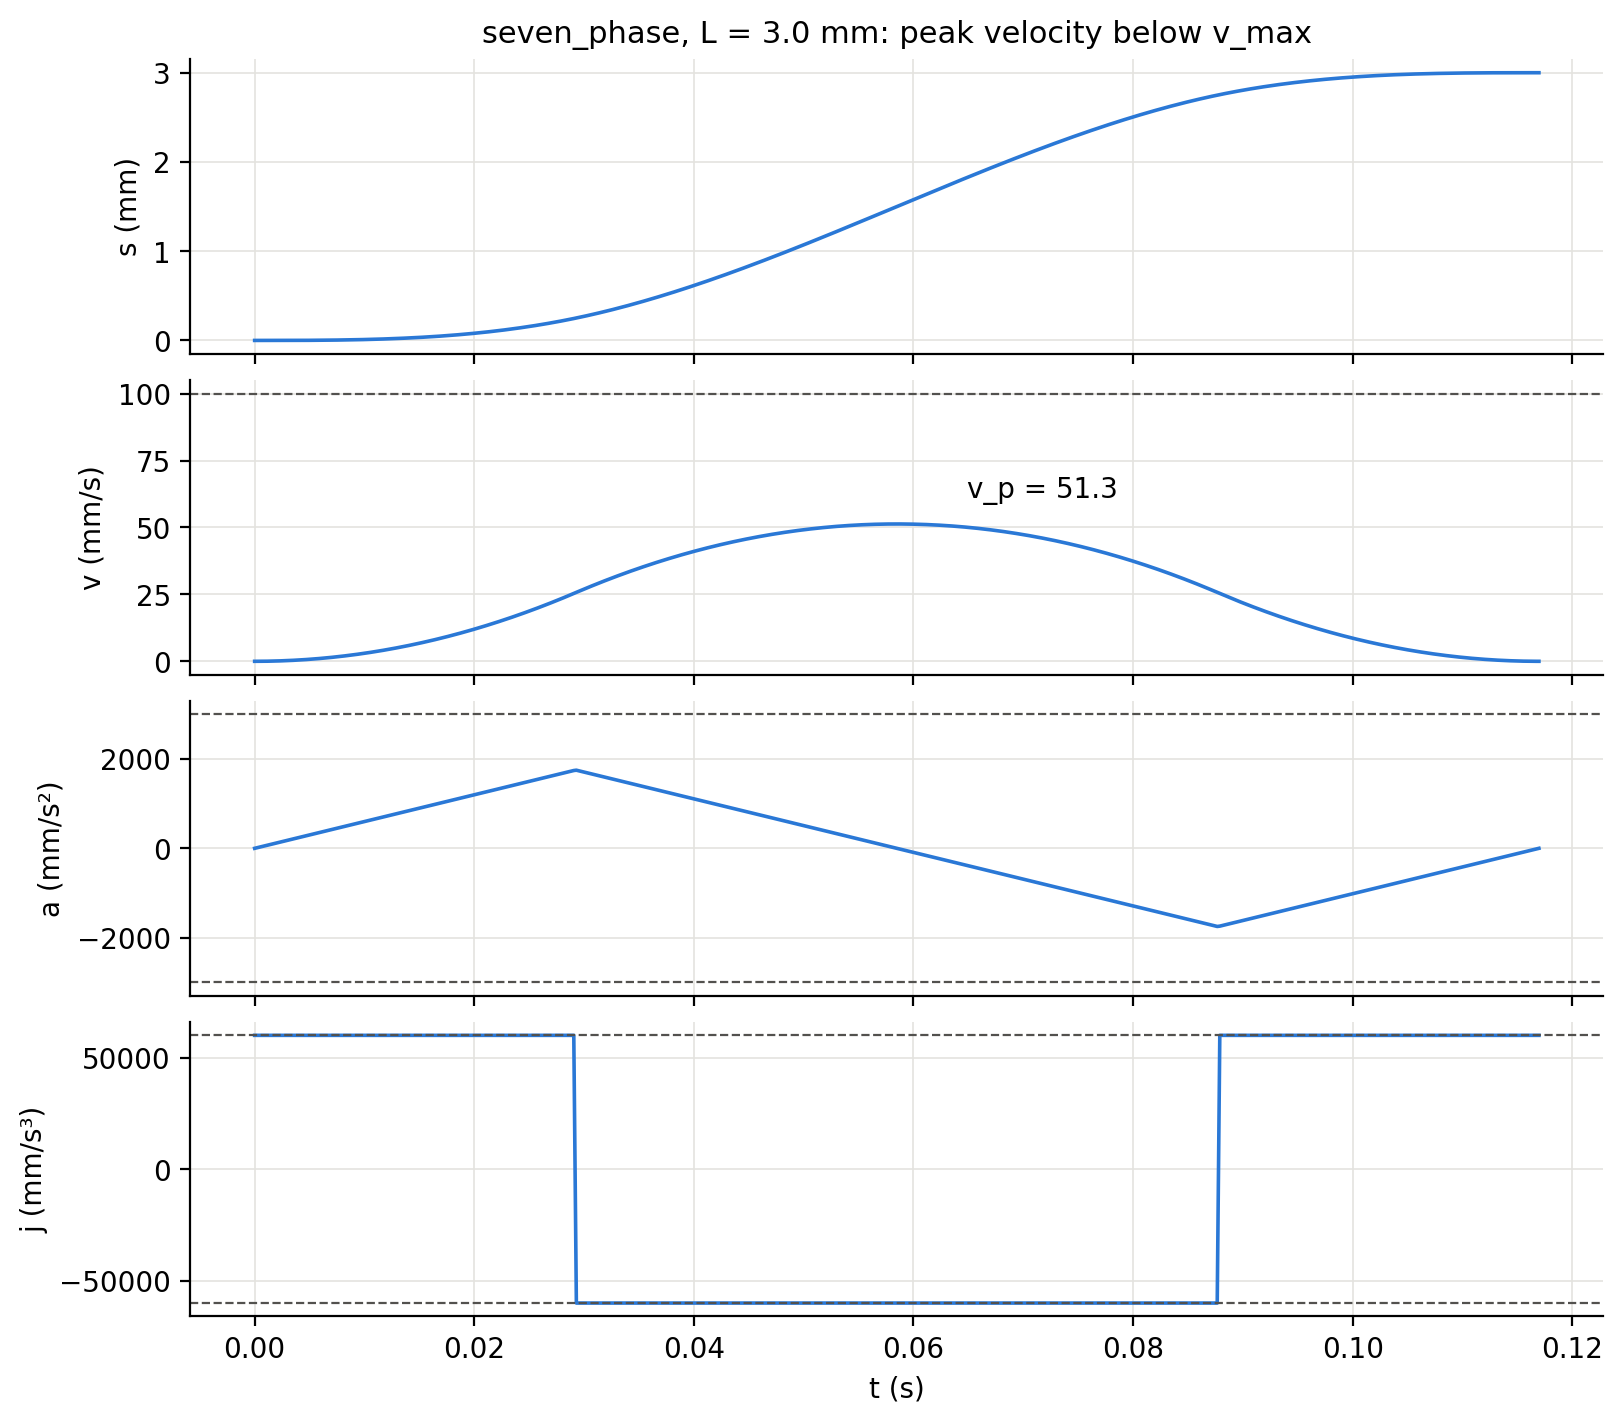

In [8]:
# 场景二：太短，到不了 v_max，峰值速度由 D(v_p) = L 解出
L = 3.0
pb = profiles.seven_phase(L, 0.0, 0.0, V_MAX, A_MAX, J_MAX)
t = np.linspace(0, pb.duration, 500)
vp = pb(t)[1].max()
axes = plotting.plot_feed(t, pb(t), limits=(V_MAX, A_MAX, J_MAX))
axes[1].annotate(f"v_p = {vp:.1f}", xy=(0.55, 0.6), xycoords="axes fraction")
axes[0].set_title(f"seven_phase, L = {L} mm: peak velocity below v_max")
plt.show()

In [9]:
# 检查：峰值速度与白盒解析式 (L/2)^(2/3)·J^(1/3) 对比
vp_exact = (L / 2) ** (2 / 3) * J_MAX ** (1 / 3)
print(f"数值峰值 v_p = {vp:.6f}，解析 v_p = {vp_exact:.6f}，相对差 {abs(vp - vp_exact) / vp_exact:.2e}")
assert abs(vp - vp_exact) / vp_exact < 1e-3  # 数值峰值取自 500 个采样点，比真峰值略低
assert abs(pb.length - L) < 1e-9

数值峰值 v_p = 51.298866，解析 v_p = 51.299278，相对差 8.03e-06


In [10]:
# 场景三：长度连一次过渡都放不下——报错（前瞻会保证不发生）
try:
    profiles.seven_phase(0.001, 0.0, 10.0, V_MAX, A_MAX, J_MAX)
except ValueError as e:
    print("ValueError:", e)

ValueError: 长度不够：从 v_start = 0 变到 v_end = 10 至少要走 0.129099，只有 0.001（前瞻 bidirectional_scan 会保证相邻速度来得及衔接）


**五段 S 曲线** `five_phase`（Lin et al. 2007；Zhao et al. 2013 采用）干脆没有匀加速段：过渡的峰值加速度是 $\sqrt{J\Delta v}$。为了让它不超过 $A$，峰值速度被限制在 $\min(v_0, v_1) + A^2/J$ 以内。前提是两端速度差本身就不超过 $A^2/J$，否则没有匀加速段、怎么规划都会超 $A$，只能报错：

$$
|v_1 - v_0| \le \frac{A^2}{J} \quad (\text{五段 S 曲线的前提}) .
$$

用 `bidirectional_scan(..., phases=5)` 做前瞻时，会自动把相邻连接点的速度差截到这个范围内。下面演示违反前提时的报错。本例的机器参数 $A^2/J = 150$ mm/s $> v_{\max}$，所以五段与七段在这条参数带上总是重合的；两者的差别只在 $A^2/J < v_{\max}$ 的机器上显现。

In [11]:
# 五段：前提满足时与七段一致（这里 A²/J = 150 > v_max，cap 不起作用）
p5 = profiles.five_phase(100.0, 0.0, 0.0, V_MAX, A_MAX, J_MAX)
print(f"五段时长 {p5.duration:.6f} s，七段时长 {pa.duration:.6f} s")
# 前提 |Δv| ≤ A²/J = 150 被违反时报错
try:
    profiles.five_phase(500.0, 0.0, 200.0, 300.0, A_MAX, J_MAX)
except ValueError as e:
    print("ValueError:", e)

五段时长 1.081650 s，七段时长 1.081650 s
ValueError: |v_end − v_start| = 200 超过 a_max²/j_max = 150：五段 S 曲线没有匀加速段，峰值加速度会超过 a_max


**要点**：`seven_phase` 一个 block 内"加速—巡航—减速"，到不了 $v_{\max}$ 就解 $D(v_p)=L$；长度连过渡都放不下时报错，这正是前瞻要排除的情形。`five_phase` 没有匀加速段，前提是 $|v_1 - v_0| \le A^2/J$。

## 3. 过渡距离与可达速度

前瞻反复问两个问题：

- `transition_distance(v0, v1)`：从 $v_0$ 变到 $v_1$ 至少要走多远？（端点加速度都为零）
- `reachable_velocity(v0, L)`：从 $v_0$ 出发、走过 $L$ 后最多能达到多快？

第二个问题是第一个的反问题：解 $D(v) = L$。$D$ 关于两端对称（速度曲线关于过渡中点对称），$D(v_0, v_0) = 0$、随 $|v_1 - v_0|$ 单调增，所以反解唯一。库里用 `brentq` 求根；[../docs/路线图.md](../docs/路线图.md) 第 2 节记着改成闭式解。没有匀加速段时它就是一条三次方程（Zhao 2013 式 (f14)）：

$$
(2v_0 + \Delta v)\sqrt{\frac{\Delta v}{J}} = L
\quad\Longleftrightarrow\quad
\Delta v^3 + 4v_0\,\Delta v^2 + 4v_0^2\,\Delta v - L^2 J = 0 ,
$$

取唯一正实根即可。有匀加速段时则是二次方程。下面把无匀加速段的情形用 `np.roots` 白盒解一遍，与库函数对比。

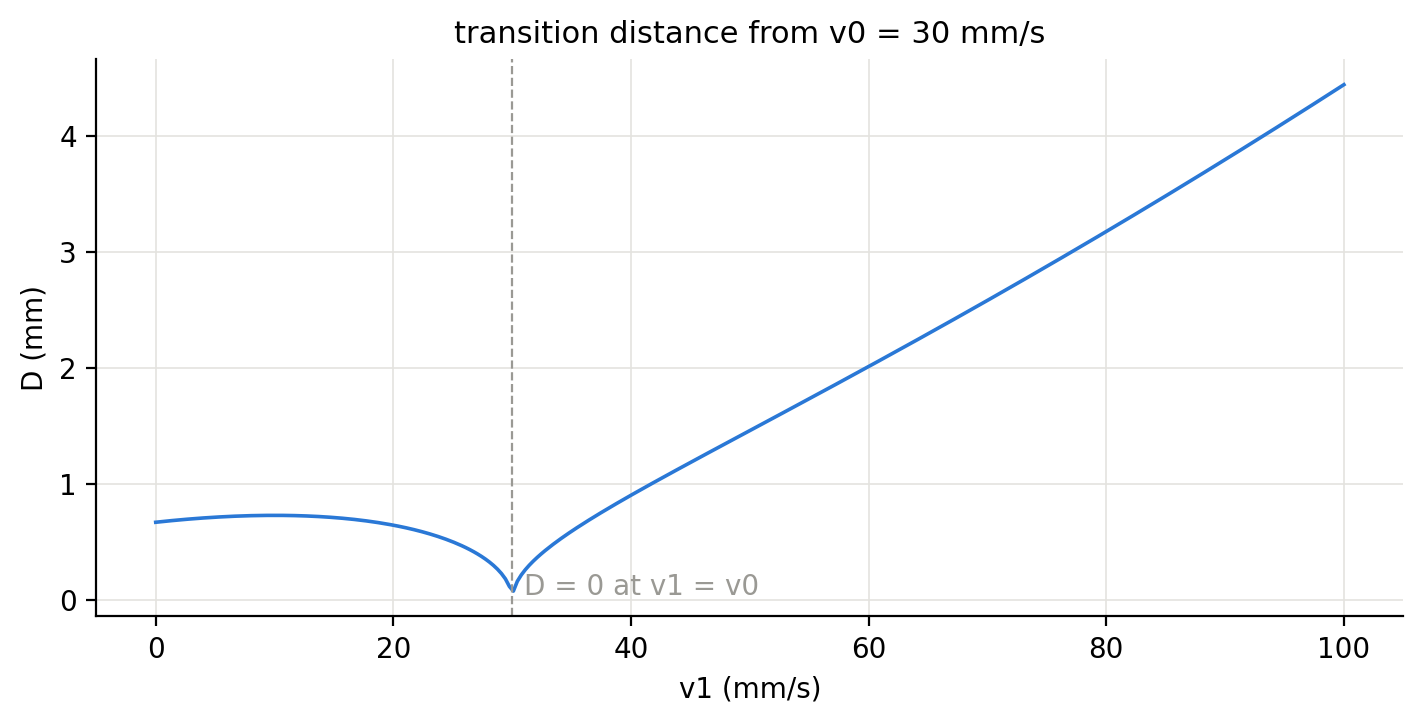

In [12]:
# 过渡距离 D(30, v1)：关于 v1 = v0 对称的"山谷"，谷底为 0
v1 = np.linspace(0.0, 100.0, 300)
D = [profiles.transition_distance(30.0, x, A_MAX, J_MAX) for x in v1]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(v1, D, color=plotting.COLORS[0])
ax.axvline(30.0, color=plotting.GRAY, ls="--", lw=0.8)
ax.annotate("D = 0 at v1 = v0", xy=(31, 0.05), color=plotting.GRAY)
ax.set(xlabel="v1 (mm/s)", ylabel="D (mm)", title="transition distance from v0 = 30 mm/s")
plt.show()

In [13]:
# 白盒：三次方程 np.roots 解 reachable_velocity，与库函数（brentq）对比
v0 = 30.0
print(f"{'L (mm)':>8} {'brentq':>14} {'closed-form':>14} {'diff':>10}")
for L in [0.2, 0.5, 1.0, 2.0, 5.0, 10.0]:
    v_r = look_ahead.reachable_velocity(v0, L, A_MAX, J_MAX)
    roots = np.roots([1.0, 4 * v0, 4 * v0**2, -(L**2 * J_MAX)])
    dv = roots[np.isreal(roots) & (roots.real > 0)].real[0]
    print(f"{L:8.2f} {v_r:14.8f} {v0 + dv:14.8f} {abs(v_r - v0 - dv):10.2e}")
    assert abs(v_r - v0 - dv) < 1e-9  # 此处 Δv ≤ A²/J，无匀加速段，三次方程精确成立

  L (mm)         brentq    closed-form       diff
    0.20    30.65240192    30.65240192   3.00e-15
    0.50    33.69702938    33.69702938   0.00e+00
    1.00    41.67822353    41.67822353   0.00e+00
    2.00    59.77700507    59.77700507   1.42e-14
    5.00   108.35794631   108.35794631   1.42e-14
   10.00   174.07266345   174.07266345   0.00e+00


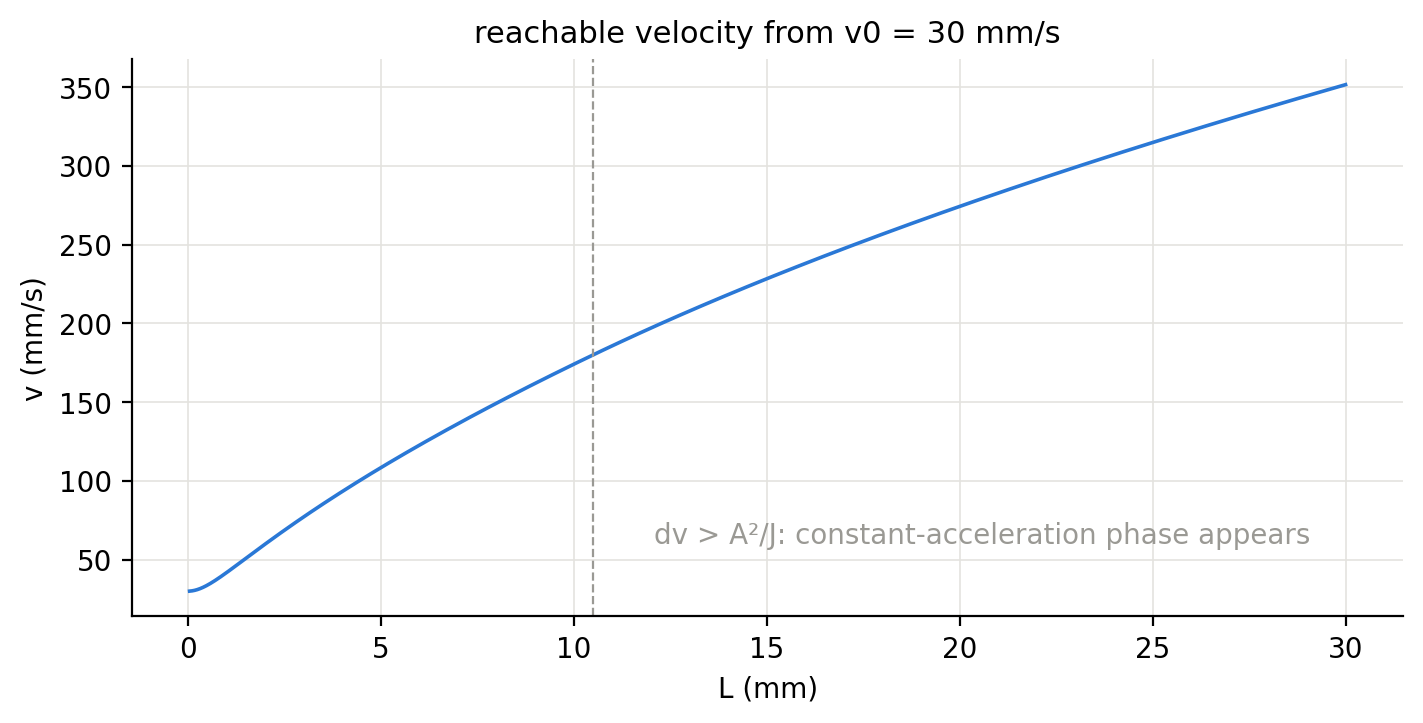

In [14]:
# reachable_velocity 随 L 的曲线；虚线右侧进入匀加速段（Δv > A²/J），三次方程不再适用
L_grid = np.geomspace(0.05, 30.0, 300)
v_r = [look_ahead.reachable_velocity(v0, L, A_MAX, J_MAX) for L in L_grid]
dv_cap = A_MAX**2 / J_MAX
L_cap = profiles.transition_distance(v0, v0 + dv_cap, A_MAX, J_MAX)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(L_grid, v_r, color=plotting.COLORS[0])
ax.axvline(L_cap, color=plotting.GRAY, ls="--", lw=0.8)
ax.annotate("dv > A²/J: constant-acceleration phase appears", xy=(L_cap * 1.15, 60), color=plotting.GRAY)
ax.set(xlabel="L (mm)", ylabel="v (mm/s)", title=f"reachable velocity from v0 = {v0:.0f} mm/s")
plt.show()

**要点**：$D$ 对称、单调，反解唯一；无匀加速段时 `reachable_velocity` 有闭式三次解（与 `brentq` 结果一致到 $10^{-9}$ 以上），有匀加速段时是二次方程。

## 4. 连接点的几何限速

block 连接点通常放在曲率的局部极大处（拐角过渡的中点、B 样条的曲率峰值）。连接点的速度上限由三条几何约束取小给出（`limits.geometric_limit`，记 $\rho = 1/\kappa$）：

$$
v_{\text{chord}} = \frac{2}{T_s}\sqrt{2\rho\delta - \delta^2}
\quad(\text{Yeh \& Hsu 2002}),\qquad
v_a = \sqrt{\frac{A}{\kappa}},\qquad
v_j = \left(\frac{J}{\kappa^2}\right)^{1/3} .
$$

第一式来自**弓高误差（chord error）**：一个插补周期走过的弦长 $c = vT_s$ 对应的弓高不超过容差 $\delta$，圆上几何给出 $(c/2)^2 = 2\rho\delta - \delta^2$。后两式是匀速过弯时的法向加速度 $v^2\kappa$ 与法向 jerk $v^3\kappa^2$。

**弓高限速的定义域要当心**（[../docs/数学约定.md](../docs/数学约定.md) 第 3 节）：弦长随 $\delta$ 增大而增大只到 $\delta = \rho$ 为止，那时弦长恰好是直径 $2\rho$。$\delta > \rho$ 时公式里的 $\delta$ 已经是优弧一侧的"弓高"，弦长反而变小，$\delta \ge 2\rho$ 时甚至给出 $v = 0$——刀具会在急弯处无谓地停车。弦长不可能超过直径，所以库里的 `chord_error_limit` 把速度**饱和**在 $2\rho/T_s$：

$$
v_{\text{chord}} =
\begin{cases}
\dfrac{2}{T_s}\sqrt{2\rho\delta - \delta^2}, & \kappa\delta \le 1,\\[2mm]
\dfrac{2\rho}{T_s}, & \kappa\delta > 1,\\[1mm]
\infty, & \kappa = 0 \ (\text{直线没有弓高误差}) .
\end{cases}
$$

急弯处的饱和值一般不起作用：那里法向加速度限速 $\sqrt{A/\kappa}$ 小得多。拐角光顺类论文把各拐角的实际逼近误差当作 $\delta$，尖拐角上就会落到 $\kappa\delta > 1$ 这一区。

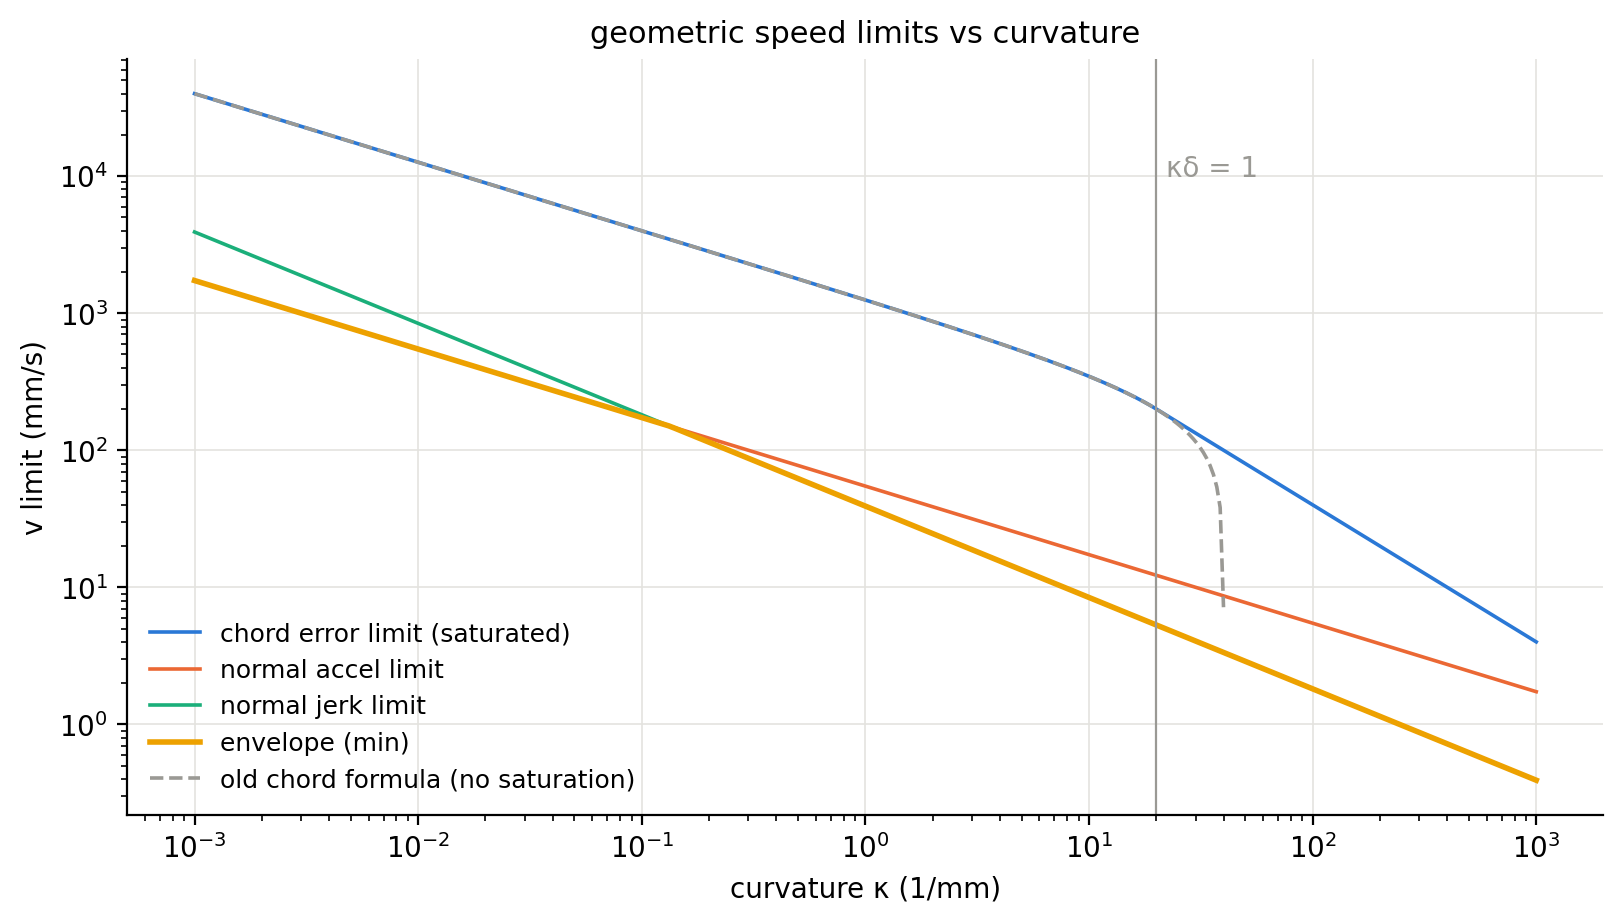

In [15]:
# 三条限速随曲率的变化（log-log）；虚线是"旧公式"：不饱和，κδ ≥ 2 时掉到 0
kappa = np.geomspace(1e-3, 1e3, 400)
delta = 0.05  # mm
v_chord = limits.chord_error_limit(kappa, delta, TS)
v_a = np.sqrt(A_MAX / kappa)
v_j = np.cbrt(J_MAX / kappa**2)
old = 2 / TS * np.sqrt(np.maximum(2 * delta / kappa - delta**2, 0.0))
old[old == 0] = np.nan
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(kappa, v_chord, color=plotting.COLORS[0], label="chord error limit (saturated)")
ax.loglog(kappa, v_a, color=plotting.COLORS[1], label="normal accel limit")
ax.loglog(kappa, v_j, color=plotting.COLORS[2], label="normal jerk limit")
ax.loglog(kappa, np.minimum.reduce([v_chord, v_a, v_j]), color=plotting.COLORS[3], lw=2, label="envelope (min)")
ax.loglog(kappa, old, ls="--", color=plotting.GRAY, label="old chord formula (no saturation)")
ax.axvline(1 / delta, color=plotting.GRAY, lw=0.8)
ax.annotate("κδ = 1", xy=(1 / delta * 1.1, 1e4), color=plotting.GRAY)
ax.set(xlabel="curvature κ (1/mm)", ylabel="v limit (mm/s)", title="geometric speed limits vs curvature")
ax.legend()
plt.show()

In [16]:
# 数值检查 1：用圆上弓高几何 δ = ρ − √(ρ² − (c/2)²) 反验 chord_error_limit
kappa_test = 0.5
rho = 1 / kappa_test
v_lim = limits.chord_error_limit(kappa_test, delta, TS)
d_back = rho - np.sqrt(rho**2 - (v_lim * TS / 2) ** 2)
print(f"κ = {kappa_test}：限速 {v_lim:.4f} mm/s → 弦长 {v_lim * TS:.6f} mm → 弓高 {d_back:.8f} mm（容差 {delta}）")
assert abs(d_back - delta) < 1e-12
# 数值检查 2：饱和区（κδ > 1）限速恰为直径 / Ts，而旧公式更小甚至为 0
for k in [30.0, 100.0]:
    print(
        f"κ = {k:5.0f}（κδ = {k * delta:.0f}）：饱和值 {limits.chord_error_limit(k, delta, TS):8.2f}，"
        f"2ρ/Ts = {2 / k / TS:8.2f}，旧公式 {2 / TS * np.sqrt(max(2 * delta / k - delta**2, 0)):.2f}"
    )
assert abs(limits.chord_error_limit(30.0, delta, TS) - 2 / 30.0 / TS) < 1e-9

κ = 0.5：限速 1777.6389 mm/s → 弦长 0.888819 mm → 弓高 0.05000000 mm（容差 0.05）
κ =    30（κδ = 2）：饱和值   133.33，2ρ/Ts =   133.33，旧公式 115.47
κ =   100（κδ = 5）：饱和值    40.00，2ρ/Ts =    40.00，旧公式 0.00


**要点**：连接点限速是弓高误差、法向加速度、法向 jerk 三者取小。弓高限速只在 $\kappa\delta \le 1$ 时随容差增大，之后饱和于直径除以 $T_s$；不饱和的旧公式会让刀具在急弯处停车。

## 5. 前瞻：双向扫描为什么两遍就够

各连接点有了速度上限 $v_{\text{lim}}$，但相邻两点之间还隔着一段长度为 $L_i$ 的 block：上限本身可能根本来不及衔接（第 2 节的报错情形）。**前瞻（look-ahead）** 的任务就是把上限序列修正成"每个 block 都来得及过渡"的速度序列。

`bidirectional_scan` 的做法简单得出奇：从后往前扫一遍，每个点压到"从下一个点出发、走过 $L_i$ 能达到的速度"以内；再从前往后扫一遍对称的操作。**为什么两遍就够**（[../docs/数学约定.md](../docs/数学约定.md) 第 3 节的论证）：记 $F_i(x)$ 为从 $x$ 出发、走过 $L_i$ 能达到的最高速度（即 `reachable_velocity`）。过渡距离关于两端对称，所以"从 $v_i$ 加速到 $v_{i+1}$ 来得及"与"从 $v_{i+1}$ 减速到 $v_i$ 来得及"是同一个条件：

$$
\text{block } i \text{ 可行} \iff v_i \le F_i(v_{i+1}) \ \text{且}\ v_{i+1} \le F_i(v_i) .
$$

反向扫描后前一个条件处处成立。正向扫描把 $v_{i+1}$ 压到 $F_i(v_i)$ 时，因为 $F$ 单调递增且 $F(x) \ge x$，有 $F_i(v_{i+1}) = F_i(F_i(v_i)) \ge v_i$，前一个条件不被破坏；其余连接点的速度只降不升，已成立的条件也不会被破坏。两遍扫完，所有条件同时成立。

下面用随机玩具数据（12 个 block）手动复现这两遍扫描，并与库函数对比。

In [17]:
# 玩具数据：随机 block 长度 + 随机连接点上限，首尾为 0（整条刀路要起步、停车）
rng = np.random.default_rng(2)
n = 12
lengths = rng.uniform(0.2, 2.0, n)
v_limit = rng.uniform(5.0, 80.0, n + 1)
v_limit[0] = v_limit[-1] = 0.0

# 手动反向扫描：v[i] 压到"从 v[i+1] 走 L_i 能达到的速度"以内
v_bwd = v_limit.copy()
for i in range(n - 1, -1, -1):
    v_bwd[i] = min(v_bwd[i], look_ahead.reachable_velocity(v_bwd[i + 1], lengths[i], A_MAX, J_MAX))

# 手动正向扫描：v[i+1] 压到"从 v[i] 走 L_i 能达到的速度"以内
v_fwd = v_bwd.copy()
for i in range(n):
    v_fwd[i + 1] = min(v_fwd[i + 1], look_ahead.reachable_velocity(v_fwd[i], lengths[i], A_MAX, J_MAX))

v_lib = look_ahead.bidirectional_scan(lengths, v_limit, A_MAX, J_MAX)
print(f"手动两遍 vs 库函数：最大差 {np.abs(v_lib - v_fwd).max():.2e}")
assert np.array_equal(v_lib, v_fwd)

手动两遍 vs 库函数：最大差 0.00e+00


In [18]:
# 检查：最终序列任意相邻两点都能在 block 长度内完成过渡（逐个 assert）
for i in range(n):
    D = profiles.transition_distance(v_lib[i], v_lib[i + 1], A_MAX, J_MAX)
    assert D <= lengths[i] * (1 + 1e-9), f"block {i}: 需要 {D}，只有 {lengths[i]}"
changed_bwd = np.sum(v_bwd < v_limit)
changed_fwd = np.sum(v_fwd < v_bwd)
print(f"{n} 个 block 的过渡距离全部放得下（反向一遍改了 {changed_bwd} 个点，正向又改了 {changed_fwd} 个）")

12 个 block 的过渡距离全部放得下（反向一遍改了 6 个点，正向又改了 4 个）


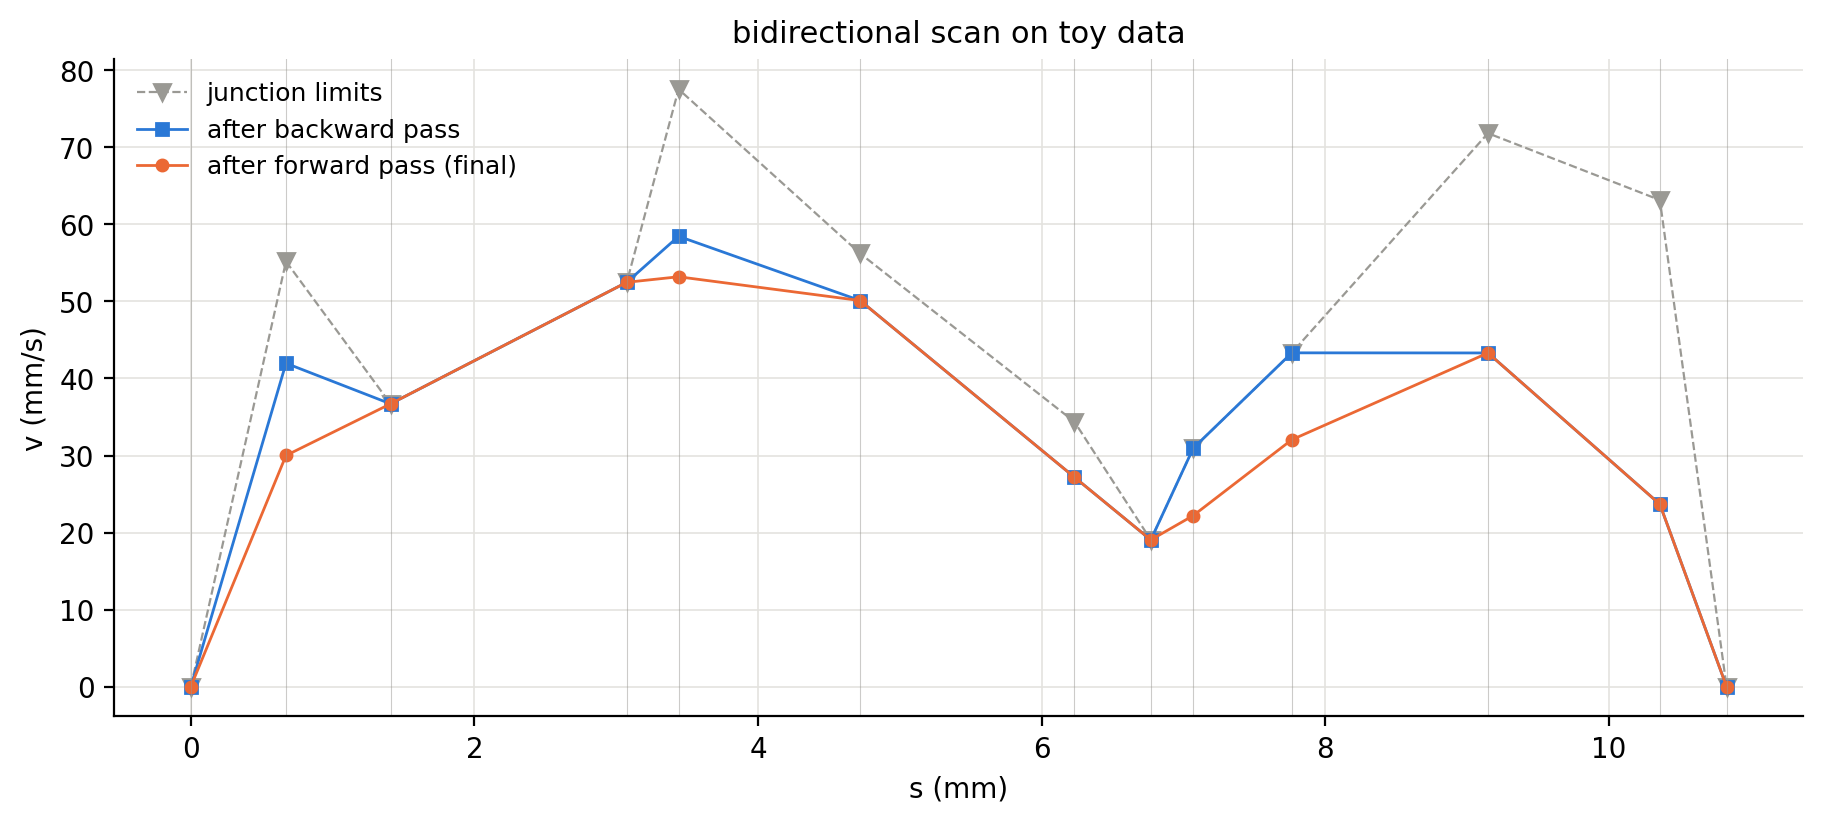

In [19]:
# 三组连接点速度：只有上限 → 反向一遍 → 正反两遍（最终）
knots = np.concatenate([[0.0], np.cumsum(lengths)])
fig, ax = plt.subplots(figsize=(9, 4))
# 速度只定义在连接点上（block 内部由 S 曲线决定），所以画成点，连线只为方便看
ax.plot(knots, v_limit, "v--", color=plotting.GRAY, ms=6, lw=0.8, label="junction limits")
ax.plot(knots, v_bwd, "s-", color=plotting.COLORS[0], ms=4, lw=1.0, label="after backward pass")
ax.plot(knots, v_lib, "o-", color=plotting.COLORS[1], ms=4, lw=1.0, label="after forward pass (final)")
for x in knots:
    ax.axvline(x, color=plotting.GRAY, lw=0.4, alpha=0.5)
ax.set(xlabel="s (mm)", ylabel="v (mm/s)", title="bidirectional scan on toy data")
ax.legend()
plt.show()

**要点**：可行性条件 $v_i \le F_i(v_{i+1})$ 且 $v_{i+1} \le F_i(v_i)$ 关于两端对称；反向一遍满足前一半，正向一遍满足后一半且（靠 $F$ 递增、$F(x) \ge x$）不破坏前一半。两遍收敛，不需要迭代。

## 6. 整条刀路：schedule 与插补后的检查

`schedule(path, v_max, a_max, j_max, Ts)` 把前面所有零件串起来：

1. `path.get_v_limit(...)` 给出各连接点的速度上限（`LinearPath` 用 Zhao et al. 2013 的拐角限速 $v \le a_{\max}T_s/(2\sin\beta)$，$\beta$ 为半转角）；
2. `bidirectional_scan` 修正成可衔接的速度序列；
3. 每个 block 用 `seven_phase`（或 `five_phase`）生成一段 S 曲线，`concatenate` 拼成一条 `Profile`；
4. 返回 `(profile, knots, v)`：进给轮廓、连接点的弧长位置和最终速度。

用 butterfly 数据（100 个点的 G01 折线，99 个 block）走一遍，画出进给速度沿弧长的分布：左图是全程，右图放大其中一段。

In [20]:
points = cx.datasets.load_dataset("butterfly").points
path = cx.LinearPath(points)
profile, knots, v_junc = cx.schedule(path, V_MAX, A_MAX, J_MAX, TS)
print(f"{len(path.blocks)} 个 block，总长 {path.length:.1f} mm")
print(profile)

99 个 block，总长 3872.8 mm
Profile(duration=44.9058 s, length=3872.75, phases=509)


被前瞻压低的连接点：0 / 100；连接点速度 < 10 mm/s 的有 60 个


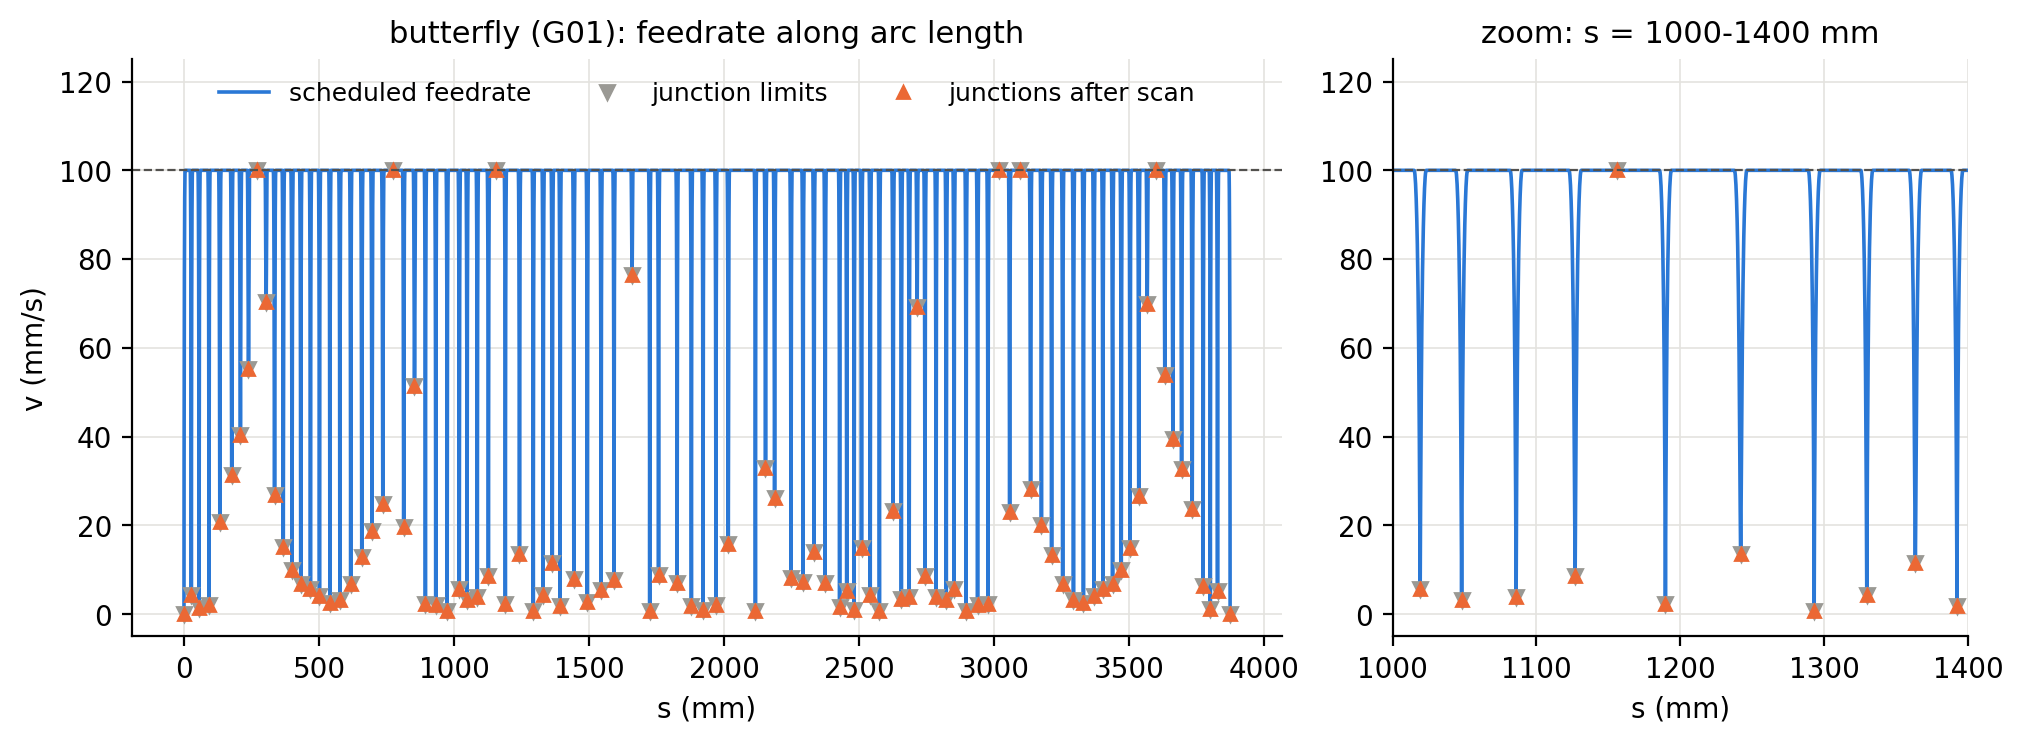

In [21]:
# 进给速度沿弧长；连接点处标出上限与扫描后的最终速度
t = np.linspace(0, profile.duration, 20000)
s_prof, v_prof = profile(t)[:2]
v_limit = path.get_v_limit(TS, V_MAX, A_MAX, J_MAX)
lowered = np.flatnonzero(v_junc < v_limit - 1e-9)
print(f"被前瞻压低的连接点：{len(lowered)} / {len(knots)}；连接点速度 < 10 mm/s 的有 {np.sum(v_junc < 10)} 个")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [2, 1]})
for ax in axes:
    ax.plot(s_prof, v_prof, color=plotting.COLORS[0], label="scheduled feedrate")
    ax.plot(knots, v_limit, "v", color=plotting.GRAY, ms=5, label="junction limits")
    ax.plot(knots, v_junc, "^", color=plotting.COLORS[1], ms=4, label="junctions after scan")
    ax.axhline(V_MAX, color=plotting.LIMIT, ls="--", lw=0.8)
    ax.set_xlabel("s (mm)")
axes[0].set(ylabel="v (mm/s)", title="butterfly (G01): feedrate along arc length", ylim=(-5, 125))
axes[1].set(xlim=(1000, 1400), ylim=(-5, 125), title="zoom: s = 1000-1400 mm")
axes[0].legend(loc="upper center", ncol=3)
plt.show()

G01 折线的拐角限速 $a_{\max}T_s/(2\sin\beta)$ 很小，进给在几乎每个拐角都降到很低（上面打印了个数），只在长直边上才达到 $v_{\max}$——这正是第 05 本拐角光顺要解决的问题。这条刀路上前瞻一个连接点也没有改：拐角限速本身已经很低，直边又足够长，相邻速度总来得及衔接。

**插补后真的不超限吗？** `interpolate` 按周期 $T_s$ 对轮廓采样，由链式法则得到刀尖对时间的导数栈；`metrics.tangential` 从导数栈提取切向速度、切向加速度、切向 jerk。由于弧长参数化下切向量严格是单位向量，这三个量应与进给轮廓的 $v$、$a$、$j$ 完全一致（上限之内）。

另一个独立的检查：`LinearPath` 的拐角限速 $v \le a_{\max}T_s/(2\sin\beta)$ 保证的是**一个插补周期内速度矢量的变化** $|\Delta\mathbf{v}| = 2v\sin\beta$ 不超过 $a_{\max}T_s$。对每个拐角找到跨过它的两个插补点，直接量 $|\Delta\mathbf{v}|$。

In [22]:
commands = cx.interpolate(path, profile, TS)
speed, accel, jerk = metrics.tangential(commands.tip)
print(f"插补点数 {len(commands.t)}，总时长 {commands.t[-1]:.3f} s（放慢倍数 λ = {commands.scale:.7f}）")
print(f"切向速度最大 {np.nanmax(speed):.2f} / {V_MAX} mm/s")
print(f"切向加速度最大 {np.nanmax(np.abs(accel)):.1f} / {A_MAX} mm/s²")
print(f"切向 jerk 最大 {np.nanmax(np.abs(jerk)):.1f} / {J_MAX} mm/s³")
assert np.nanmax(speed) <= V_MAX * (1 + 1e-9)
assert np.nanmax(np.abs(accel)) <= A_MAX * (1 + 1e-9)
assert np.nanmax(np.abs(jerk)) <= J_MAX * (1 + 1e-9)

插补点数 89813，总时长 44.906 s（放慢倍数 λ = 1.0000036）
切向速度最大 100.00 / 100.0 mm/s
切向加速度最大 2439.6 / 3000.0 mm/s²
切向 jerk 最大 59999.4 / 60000.0 mm/s³


In [23]:
# 拐角检查：跨过每个拐角的相邻两插补点，速度矢量变化 |Δv| 与 a_max·Ts 之比
vel = commands.tip[1]
ratios = []
for k in range(1, len(knots) - 1):
    i = min(np.searchsorted(commands.feed[0], knots[k]) - 1, len(vel) - 2)
    ratios.append(np.linalg.norm(vel[i + 1] - vel[i]) / (A_MAX * TS))
print(f"|Δv| / (a_max·Ts) 最大 = {max(ratios):.4f}")
assert (
    max(ratios) < 1.02
)  # 略大于 1：|Δv| 还含切向速度的变化——连接点处 a = 0，但 jerk 已经起步，一个周期后 a·Ts 不再为零

|Δv| / (a_max·Ts) 最大 = 1.0043


**要点**：`schedule` = 连接点限速 + 双向扫描 + 逐 block S 曲线 + 拼接。插补后切向 $v, a, j$ 都在上限以内，拐角处一个周期的速度矢量变化不超过 $a_{\max}T_s$（样本上超出千分之几：跨过拐角的两个插补点之间，切向速度也在变化，这部分不在拐角限速的推导里）。

## 7. 练习

1. 把第 1 节的 `a_demo` 从 1000 改成 500，观察梯形过渡的时长变化，并用解析公式 $T = \Delta v/A + A/J$ 验证。$A$ 减半，$T$ 一定变长吗？对哪个 $\Delta v$ 取到最短？
2. 第 2 节把 `L = 3.0` 逐渐加大，找到"刚好达到 $v_{\max}$"的临界长度，并用 `transition_distance(0, V_MAX, ...)` 的两倍验证它。
3. 第 5 节换几个随机种子，数一数反向扫描后被正向扫描**再次**压低的连接点个数——能找到正向一遍一个都不改的数据吗？这说明两遍中哪一遍"真正起作用"取决于数据。
4. 第 4 节把 `delta` 改成 0.001（很严的容差），重新画 log-log 图：三条限速的相对位置怎么变？哪个机制在低速区接管了包络？
5. 第 3 节把 `a_max` 从 3000 降到 1000（$A^2/J$ 从 150 降到 16.7），重新画 reachable_velocity 曲线：进入匀加速段的临界 $L$ 明显提前，$v$ 随 $L$ 的增速变慢——这正是 `five_phase` 用无匀加速段的前提 $|\Delta v| \le A^2/J$ 决定了它与 `seven_phase` 只在 $A^2/J \ge v_{\max}$ 时重合。

## 延伸阅读

- [../docs/数学约定.md](../docs/数学约定.md) 第 3 节（刀路、block 与前瞻：弓高限速定义域、双向扫描的论证、block 结构的局限）与第 4 节（进给轮廓：transition、seven_phase、five_phase 的前提）；
- [../docs/路线图.md](../docs/路线图.md) 第 2 节（`reachable_velocity` 改闭式解、block 结构之外的调度器、把切向项放进包络）；
- 进给包络 `feed_envelope`（block 内部也限速）与五轴各轴约束见第 [06](06_五轴与机床轴.ipynb) 本；G01 在拐角几乎停车的问题见第 [05](05_拐角光顺.ipynb) 本；
- 文献：Yeh & Hsu 2002（弓高限速）、Lin et al. 2007（五段 S 曲线与双向扫描）、Zhao et al. 2013（拐角限速，见 `papers/Zhao2013/`）、Lai et al. 2008（法向 jerk 限速）。